In [265]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

In [266]:
with open("../data/names.txt", 'r') as f:
    words = f.read().splitlines()

In [267]:
start = ord('a'); end = start + 26
chs = [chr(i) for i in range(start, end)]

stoi = {s:i+1 for i, s in enumerate(chs)}
stoi['.'] = 0

itos = {i:s for s, i in stoi.items()}

In [268]:

def build_dataset(words):

    X, y = [], []

    blocksize = 3
    for w in words:
        context = [0] * blocksize

        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            y.append(ix)
            # print(''.join(itos[i] for i in context) + '--->' + itos[ix])
            context = context[1:] + [ix]

    X = torch.tensor(X)
    y = torch.tensor(y)

    return X, y

random.seed(101)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

X_train, y_train = build_dataset(words[:n1])
X_dev, y_dev = build_dataset(words[n1:n2])
X_test, y_test = build_dataset(words[n2:])


### initializing :

In [269]:
g = torch.Generator().manual_seed(2147483647)

emb_size = 10
block_size = 3
hidden_size = 200
vocb_size = 27

C = torch.randn((vocb_size, emb_size)) * 0.1

W1 = torch.randn((emb_size * block_size, hidden_size), generator=g) * 0.1
b1 = torch.zeros(hidden_size) 
W2 = torch.randn((hidden_size, vocb_size), generator=g) * 0.1
b2 = torch.zeros(vocb_size)

parameters = [C, W1, b1, W2, b2]



In [270]:
sum(p.nelement() for p in parameters)

11897

In [271]:
for p in parameters:
    p.requires_grad = True

## Finding a descent learning rate

In [272]:
# choosing the learning rate between 0.001 and 1
lre = torch.linspace(-3, 0, 1001)
lrs = 10 ** lre

In [273]:
lrei = []
losses = []
stepi = []

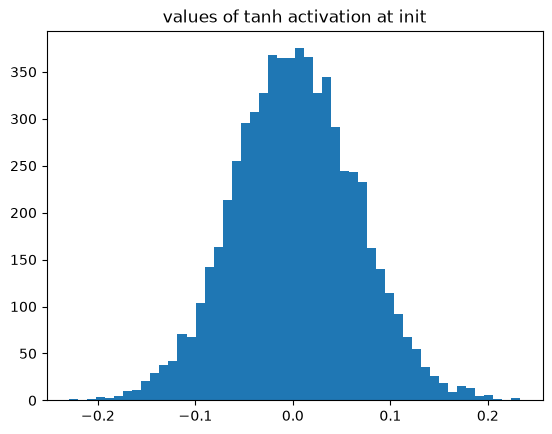

the loss is : 3.2690589427948
the loss is : 3.278186082839966
the loss is : 3.21889328956604
the loss is : 3.2104668617248535
the loss is : 3.141436815261841
the loss is : 3.0733249187469482
the loss is : 2.5400710105895996
the loss is : 2.8167154788970947
the loss is : 2.2709596157073975
the loss is : 2.728179931640625
the loss is : 2.2295291423797607


In [274]:
batch_size = 32
epochs = 1001

for i in range(epochs):
    # construct mini batches
    ix = torch.randint(0, X_train.shape[0], (batch_size,))

    # forward pass
    emb = C[X_train[ix]] # (inputs, block_size, emb_size)
    Z1 = emb.view((-1, block_size * emb_size)) @ W1 + b1 # (inputs, outputs1 )
    A1 = Z1.tanh() # (inputs, outputs1 )
    Z2 = A1 @ W2 + b2 # (inputs, outputs2 )
    loss = F.cross_entropy(Z2, y_train[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data -= lrs[i] * p.grad

    lrei.append(lre[i])
    losses.append(loss.item())
    stepi.append(i)
    
    if i == 0:
        # fixing the saturated tanh at init
        plt.hist(A1.view(-1).tolist(), 50)
        plt.title("values of tanh activation at init")
        plt.show()

    if i % (epochs // 10) == 0:
        print(f"the loss is : {loss.item()}")

    


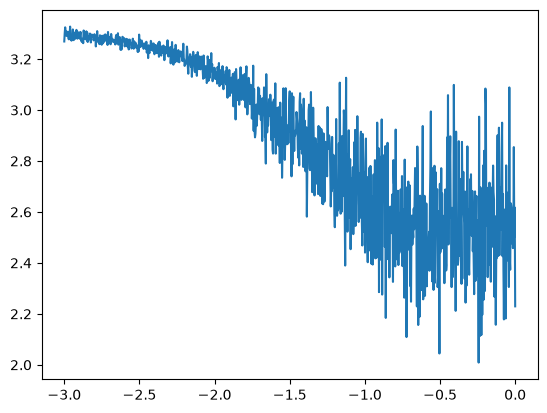

In [275]:
plt.plot(lrei, losses)

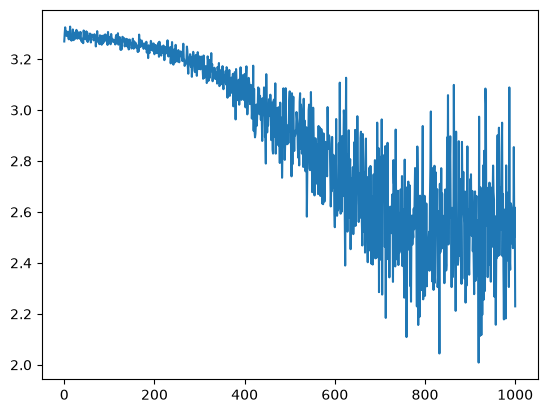

In [276]:
plt.plot(stepi, losses)

### reinitializing :

In [277]:
g = torch.Generator().manual_seed(2147483647)

emb_size = 10
block_size = 3
hidden_size = 200
vocb_size = 27

C = torch.randn((vocb_size, emb_size)) * 0.1

W1 = torch.randn((emb_size * block_size, hidden_size), generator=g) * 0.1
b1 = torch.zeros(hidden_size) 
W2 = torch.randn((hidden_size, vocb_size), generator=g) * 0.1
b2 = torch.zeros(vocb_size)

parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

sum(p.nelement() for p in parameters)

11897

In [278]:
losses = []
stepi = []

In [279]:
batch_size = 128
epochs = 200000

for i in range(epochs):
    # construct mini batches
    ix = torch.randint(0, X_train.shape[0], (batch_size,))

    # forward pass
    emb = C[X_train[ix]] # (inputs, 3, 2)
    Z1 = emb.view((-1, block_size * emb_size)) @ W1 + b1 # (inputs, outputs1 : 100)
    A1 = Z1.tanh() # (inputs, outputs 1 : 100)
    Z2 = A1 @ W2 + b2 # (inputs, outputs2 : 27)
    loss = F.cross_entropy(Z2, y_train[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update

    step = 0.1 if i < (epochs / 2) else 0.01
    for p in parameters:
        p.data -= step * p.grad

    stepi.append(i)
    losses.append(loss.item())

    

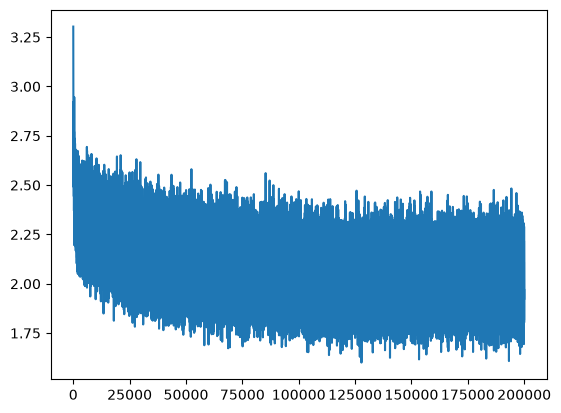

In [280]:
plt.plot(stepi, losses)

In [281]:
emb = C[X_train]
Z1 = emb.view(-1, emb_size * block_size) @ W1 + b1
A1 = Z1.tanh()
Z2 = A1 @ W2 + b2

loss = F.cross_entropy(Z2, y_train)
loss.item()

2.023951530456543

In [282]:
emb = C[X_dev]
Z1 = emb.view(-1, block_size * emb_size) @ W1 + b1
A1 = Z1.tanh()
Z2 = A1 @ W2 + b2

loss = F.cross_entropy(Z2, y_dev)
loss.item()

2.105559825897217

In [284]:
array = torch.tensor([[1, 2, 3],
                      [4, 5, 6],
                      [7, 8, 9]]) # (3, 3)

out1 = array.sum(dim=0, keepdim=False)
out2 = array.sum(dim=0, keepdim=True)

print(out1)
print(out2)

tensor([12, 15, 18])
tensor([[12, 15, 18]])
